# Tutorial: Lifetime based analysis

Paul, write this quick tutorial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

--------------------------------------------------------------
 You are running smfBursts (version 1.0.1).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


## Pre-processing: Burst Search and Correction Factors

First we load the data

In [2]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

Then make burst searches to compute correction factors 
(see the [correction factors tutorial](FRETCorrectionsTutorial.ipynb) for more detailed tutorial of how to compute these).
Corrections are needed for accurate FRET, which is necessary for E-$\tau$ analysis.

In [3]:
# Background analysis
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4)
# burst search for correction factors
dbs_acbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex_1ex1em'),))
gate_acbs = smf.make_geq_gate(dbs_acbs['NphActive_bg'], 50.0)
# burst search (dcbs) for E-tau analysis
dbs_dcbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))
gate_dcbs = smf.make_geq_gate(dbs_dcbs['NphDex_bg'], 50.0) & smf.make_geq_gate(dbs_dcbs['NphAA_bg'], 30.0)

Plot and define thresholds for DO, AO and FRET populations

(-0.2, 1.2)

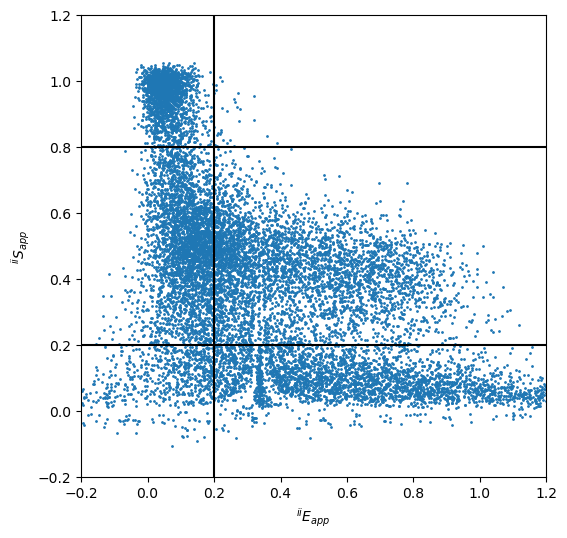

In [4]:
DO_thresh = 0.8
DO_ethresh = 0.2
AO_thresh = 0.2

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_acbs['E_bg'], dbs_acbs['S_bg'], gate=gate_acbs, ax=ax, s=1.0)
ax.axhline(DO_thresh, c='k')
ax.axvline(DO_ethresh, c='k')
ax.axhline(AO_thresh, c='k')

ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

Build gates and compute $\alpha$ and $\delta$ cross-talk corrections

In [5]:
gate_do = gate_acbs & smf.make_geq_gate(dbs_acbs['S_bg'], DO_thresh) & smf.make_lt_gate(dbs_acbs['E_bg'], DO_ethresh)
gate_ao = gate_acbs & smf.make_lt_gate(dbs_acbs['S_bg'], AO_thresh)

alpha = smf.fretfactory.crosstalk_correction(data, dbs_acbs['E_bg'], gate=gate_do)
delta = smf.fretfactory.crosstalk_correction(data, dbs_acbs['S_bg'], gate=gate_ao)

dbs_dcbs_ct = smf.fretfactory.make_correction_facors(dbs_dcbs['nphbg'], alpha=alpha, delta=delta)

Check FRET populations.

(-0.2, 1.2)

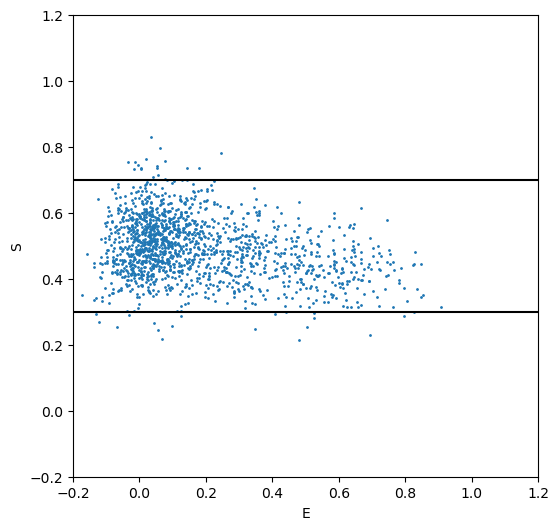

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_dcbs_ct['E'], dbs_dcbs_ct['S'], gate=gate_dcbs, ax=ax, s=1.0)
ax.axhline(minS, c='k')
ax.axhline(maxS, c='k')

In this case the dcbs looks good, we can use the global burst fit without further gating. In other cases, you may want to set $S$ thresholds to isolate the FRET population, or fit positions.

We can now compute the $\gamma$ and $\beta$ values.

In [8]:
gamma, beta = smf.fretfactory.gamma_beta_bursts(data, dbs_dcbs_ct['E'], dbs_dcbs_ct['S'], gate=gate_dcbs)
dbs_dcbs_full = smf.fretfactory.make_correction_facors(dbs_dcbs['nphbg'], alpha=alpha, delta=delta, gamma=gamma, beta=beta)

## E-$\tau$ analysis

To compute mean lifetimes, we must first set thresholds for excluding the IRF from computation of mean lifetimes.

We can visualize the decays by summing the `nanohist` column:

In [11]:
Nhst_DD = smf.Column(dbs_dcbs['bursts'], 'nanohist', (smf.PhSel('0ex0em'), True))
hstDD = data.get_column(Nhst_DD, gate=gate_dcbs).sum(axis=0)
Nhst_DA = smf.Column(dbs_dcbs['bursts'], 'nanohist', (smf.PhSel('0ex1em'), True))
hstDA = data.get_column(Nhst_DA, gate=gate_dcbs).sum(axis=0)
Nhst_AA = smf.Column(dbs_dcbs['bursts'], 'nanohist', (smf.PhSel('1ex1em'), True))
hstAA = data.get_column(Nhst_AA, gate=gate_dcbs).sum(axis=0)

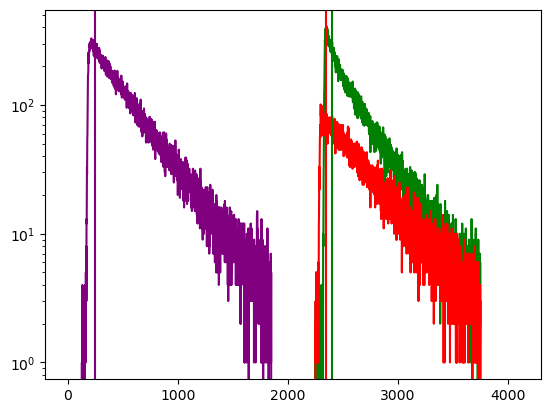

In [16]:
plt.semilogy(hstDD, label='DD', c='g')
plt.semilogy(hstDA, label='DA', c='r')
plt.semilogy(hstAA, label='AA', c='purple')

threshDD = 2400
threshDA = 2350
threshAA = 250

plt.axvline(threshDD, c='g')
plt.axvline(threshDA, c='r')
plt.axvline(threshAA, c='purple')

Now that the thresholds to exclude the IRF are decided, we set the `data.irf_thresh` dictionary accordingly:

In [20]:
data.irf_thresh = {smf.PhSel('0ex0em'):threshDD, smf.PhSel('0ex1em'):threshDA, smf.PhSel('1ex1em'):threshAA}

And we can define the column for mean lifetime:

In [18]:
nanomean = smf.Column(dbs_dcbs['bursts'], 'nanomean', smf.PhSel('0ex0em'))

A simple histogram plot will only show as much as a standard FRET histogram:

(array([  0,   0,   0,   0,   0,   0,   0,   1,   0,   1,   1,   4,   2,
          1,   4,   2,   7,   3,   3,   5,   6,   8,  10,  17,  18,  32,
         37,  42,  59,  71,  79,  97,  99, 125,  86, 110,  95,  80,  75,
         78,  58,  50,  35,  25,  24,  14,  18,   5,   4]),
 array([0.        , 0.10204082, 0.20408163, 0.30612245, 0.40816327,
        0.51020408, 0.6122449 , 0.71428571, 0.81632653, 0.91836735,
        1.02040816, 1.12244898, 1.2244898 , 1.32653061, 1.42857143,
        1.53061224, 1.63265306, 1.73469388, 1.83673469, 1.93877551,
        2.04081633, 2.14285714, 2.24489796, 2.34693878, 2.44897959,
        2.55102041, 2.65306122, 2.75510204, 2.85714286, 2.95918367,
        3.06122449, 3.16326531, 3.26530612, 3.36734694, 3.46938776,
        3.57142857, 3.67346939, 3.7755102 , 3.87755102, 3.97959184,
        4.08163265, 4.18367347, 4.28571429, 4.3877551 , 4.48979592,
        4.59183673, 4.69387755, 4.79591837, 4.89795918, 5.        ]),
 <BarContainer object of 49 artists>,
 

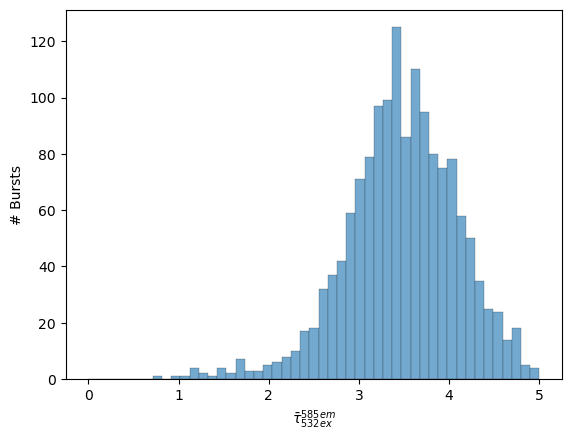

In [24]:
smf.plot.hist_bar(data, nanomean, gate=gate_dcbs, rescale=-9, bins=np.linspace(0, 5.0, 50), **smf.fretfactory.ALEXdefaults['histbar'])

But plotting E vs $\tau$ can show evidence of dynamics (if the expected 0 fret lifetime is known)

(<matplotlib.collections.PathCollection at 0x7b1f8049d4c0>,
 Text(0.5, 0, 'E'),
 Text(0, 0.5, '$\\bar \\tau_{532ex}^{585em}\\: (ns)$'))

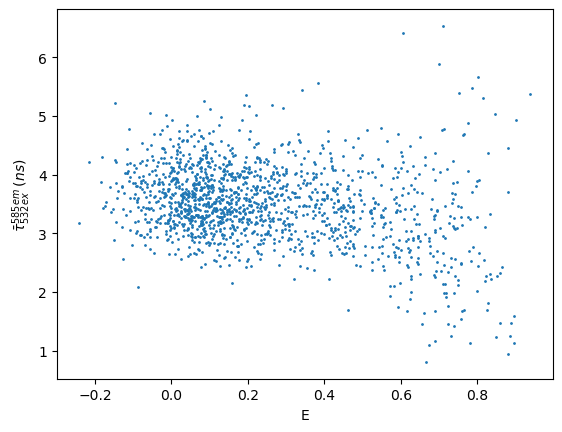

In [26]:
smf.plot.scatter(data, dbs_dcbs_full['E'], nanomean, gate=gate_dcbs, s=1.0, rescale=(0, -9))